# Drift

Step 10.1. The steady states of the Phase 5 model (`ackermann_nmpc/model.py`) with the steering
angle and the rear wheel speed held, the two things the car is commanded: which drifts exist,
which hold by themselves, and which leave room for a cone at the centre of the circle.

In [1]:
import sys
sys.path.append('../ros2_ws/src/ackermann_nmpc')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import casadi as ca
import yaml
from scipy.optimize import fsolve
from ackermann_nmpc.model import forces

plt.rcParams['figure.dpi'] = 72
p = yaml.safe_load(open('../ros2_ws/src/ackermann_description/config/vehicle_params.yaml'))['/**']['ros__parameters']

# vx, vy, r derivatives with steering d, wheel speed u and friction mu_scale held
z_, inputs_ = ca.SX.sym('z', 3), ca.SX.sym('in', 3)
fx, fy, mz = forces(p, z_[0], z_[1], z_[2], inputs_[0], inputs_[1], inputs_[2])
f = ca.Function('f', [z_, inputs_], [ca.vertcat(fx / p['mass'] + z_[1] * z_[2], fy / p['mass'] - z_[0] * z_[2], mz / p['iz'])])
jac = ca.Function('f_jacobian', [z_, inputs_], [ca.jacobian(f(z_, inputs_), z_)])


GRID = [(vx, vx * np.tan(beta), r) for vx in np.linspace(0.15, 1.3, 6)
        for beta in np.radians(np.linspace(-45, 10, 8)) for r in np.linspace(0.5, 6, 8)]
DRIFT_GUESSES = [(0.6, -0.3, 2.0), (1.0, -0.6, 1.5), (0.8, -0.5, 3.0), (0.5, -0.15, 3.5), (0.4, -0.3, 2.5)]


def steady(d, u, mu=1.0, guesses=GRID):
    # the steady states (vx, vy, r) turning left reached from the starting points
    found = []
    for g in guesses:
        z, _, ok, _ = fsolve(lambda z: np.array(f(z, [d, u, mu])).ravel(), g, full_output=True)
        if ok == 1 and np.abs(np.array(f(z, [d, u, mu]))).max() < 1e-9 and z[0] > 0.1 and z[2] > 0 \
                and not any(np.allclose(z, s, atol=1e-4) for s in found):
            found.append(z)
    return found


def describe(z, d, u, mu=1.0):
    vx, vy, r = z
    V, beta = np.hypot(vx, vy), np.arctan2(vy, vx)
    eig = np.linalg.eigvals(np.array(jac(z, [d, u, mu])))
    return {'R [m]': V / r, 'V [m/s]': V, 'r [rad/s]': r, 'beta cg [deg]': np.degrees(beta),
            'rear slip [deg]': np.degrees(np.arctan2(vy - p['lr'] * r, vx)), 'stable': eig.real.max() < 0,
            'slowest eigenvalue [1/s]': eig.real.max()}

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## The donut

The steady donut of the Phase 5 drift runs (full left lock, command 0.52, wheels at 1.12 m/s)
against the steady states of the model at the same steering and wheel speed.

In [2]:
rows = []
for run in ['id_drift', 'val_drift']:
    df = pd.read_parquet(f'../data/sysid/{run}.parquet')
    cmd = df['cmd_speed'].ffill()
    w = (cmd > 1.2) & (df['t'] > df['t'][cmd > 1.2].min() + 2)
    rows.append({'': run, 'R [m]': (df['v_cg'][w] / df['r'][w]).mean(), 'V [m/s]': df['v_cg'][w].mean(),
                 'r [rad/s]': df['r'][w].mean(), 'beta cg [deg]': df['beta_cg'][w].mean(),
                 'rear slip [deg]': df['beta_rear'][w].mean(), 'wheels [m/s]': df['v_wheels'][w].mean()})
d_lock = np.interp(0.52, p['steer_cmd'], p['steer_angle'])
for z in steady(d_lock, 1.12):
    rows.append({'': 'model', **describe(z, d_lock, 1.12), 'wheels [m/s]': 1.12})
pd.DataFrame(rows).round(3)

,,R [m],V [m/s],r [rad/s],beta cg [deg],rear slip [deg],wheels [m/s],stable,slowest eigenvalue [1/s]
0,id_drift,0.140,0.498,3.56,-21.187,-43.566,1.122,NaN,NaN
1,val_drift,0.146,0.515,3.54,-17.990,-40.533,1.115,NaN,NaN
2,model,0.122,0.486,3.99,-18.001,-44.043,1.120,True,-1.313


## Three steady states

With the same steering and wheel speed the model has up to three: grip, a saddle and a drift. The
drift holds by itself: the firmware keeps the wheels at their speed and so the rear slip, where
a torque command would let it run away. Getting into it takes a push across the saddle, and it
ends when the wheel speed drops below the fold, as in the Phase 5 runs.

In [3]:
rows = []
for d_deg, u in [(23, 1.05), (17, 1.10)]:
    for z in sorted(steady(np.radians(d_deg), u), key=lambda z: -z[1]):
        rows.append({'steering [deg]': d_deg, 'wheels [m/s]': u, **describe(z, np.radians(d_deg), u)})
pd.DataFrame(rows).round(3)

,steering [deg],wheels [m/s],R [m],V [m/s],r [rad/s],beta cg [deg],rear slip [deg],stable,slowest eigenvalue [1/s]
0,23,1.05,0.417,0.913,2.190,5.899,-4.355,True,-4.070
1,23,1.05,0.251,0.776,3.092,-2.533,-18.830,False,1.065
2,23,1.05,0.181,0.639,3.539,-9.555,-30.380,True,-1.230
3,17,1.10,0.575,1.012,1.760,4.853,-2.573,True,-5.268
4,17,1.10,0.284,0.838,2.949,-5.726,-19.980,False,1.626
5,17,1.10,0.187,0.648,3.476,-15.086,-34.320,True,-0.765


## What the car can hold

Every steady state with the rear sliding more than 20 deg, for the steering the car has
(-21.8 to +28.9 deg) and wheel speeds up to the motor's 1.2 m/s.

In [4]:
rows = []
for d_deg in np.arange(-21, 29, 1.0):
    for u in np.arange(0.6, 1.201, 0.02):
        for z in steady(np.radians(d_deg), u, guesses=DRIFT_GUESSES):
            s = describe(z, np.radians(d_deg), u)
            if s['rear slip [deg]'] < -20:
                rows.append({'steering [deg]': d_deg, 'wheels [m/s]': u, **s})
drifts = pd.DataFrame(rows)
drifts.groupby('stable')[['R [m]', 'V [m/s]', 'beta cg [deg]', 'rear slip [deg]']].agg(['min', 'max']).round(2)

R [m]       V [m/s]       beta cg [deg]       rear slip [deg]       
         min   max     min   max           min   max             min    max
stable                                                                     
False   0.25  0.36    0.77  0.97        -18.79 -4.44          -33.34 -20.05
True    0.11  0.19    0.45  0.66        -25.19 -5.54          -49.58 -27.22

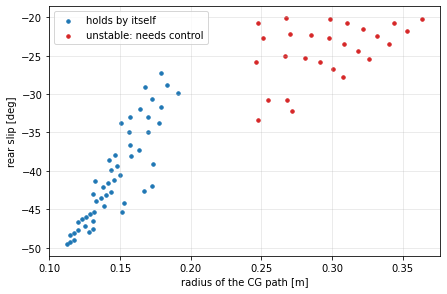

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for stable, c, label in [(True, 'C0', 'holds by itself'), (False, 'C3', 'unstable: needs control')]:
    s = drifts[drifts['stable'] == stable]
    ax.scatter(s['R [m]'], s['rear slip [deg]'], s=12, c=c, label=label)
ax.set_xlabel('radius of the CG path [m]')
ax.set_ylabel('rear slip [deg]')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Around a cone

The centre of the circle seen from the car, against the outline of the URDF (body 0.26 x 0.13 m,
wheels to +-0.10 m): the widest drift that holds by itself, and the widest one within the motor.

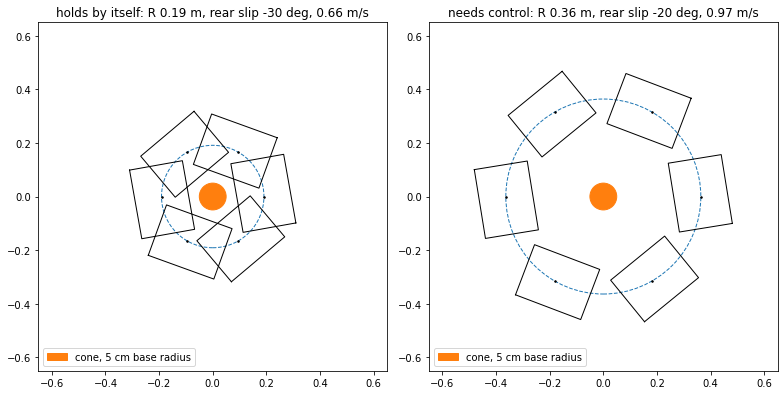

,steering [deg],wheels [m/s],R [m],V [m/s],r [rad/s],beta cg [deg],rear slip [deg],stable,slowest eigenvalue [1/s],clearance [m]
34,21.0,1.06,0.191,0.662,3.464,-10.099,-29.845,True,-1.084,0.088
12,9.0,1.20,0.364,0.966,2.655,-9.208,-20.273,False,2.771,0.259


In [6]:
OUTLINE = np.array([[-0.0435, -0.1], [0.2165, -0.1], [0.2165, 0.1], [-0.0435, 0.1], [-0.0435, -0.1]])   # rear axle frame


def clearance(R, beta):
    # distance from the centre of the circle to the outline
    cx, cy = p['lr'] - R * np.sin(np.radians(beta)), R * np.cos(np.radians(beta))
    return np.hypot(max(-0.0435 - cx, 0, cx - 0.2165), max(-0.1 - cy, 0, cy - 0.1))


drifts['clearance [m]'] = [clearance(R, b) for R, b in zip(drifts['R [m]'], drifts['beta cg [deg]'])]
picks = pd.concat([drifts[drifts['stable']].nlargest(1, 'R [m]'), drifts[~drifts['stable']].nlargest(1, 'R [m]')])
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
for a, (_, s) in zip(ax, picks.iterrows()):
    R, beta = s['R [m]'], np.radians(s['beta cg [deg]'])
    for th in np.linspace(0, 2 * np.pi, 7)[:-1]:
        heading = th + np.pi / 2 - beta          # the velocity is tangent, beta off the heading
        cg = R * np.array([np.cos(th), np.sin(th)])
        rear = cg - p['lr'] * np.array([np.cos(heading), np.sin(heading)])
        rot = np.array([[np.cos(heading), -np.sin(heading)], [np.sin(heading), np.cos(heading)]])
        body = rear + OUTLINE @ rot.T
        a.plot(body[:, 0], body[:, 1], 'k', lw=1)
        a.plot(*cg, 'k.', ms=3)
    a.add_patch(plt.Circle((0, 0), 0.05, color='C1', label='cone, 5 cm base radius'))
    a.add_patch(plt.Circle((0, 0), R, fill=False, ls='--', color='C0'))
    a.set_aspect('equal')
    a.set_xlim(-0.65, 0.65)
    a.set_ylim(-0.65, 0.65)
    a.set_title(f"{'holds by itself' if s['stable'] else 'needs control'}: R {R:.2f} m, "
                f"rear slip {s['rear slip [deg]']:.0f} deg, {s['V [m/s]']:.2f} m/s")
    a.legend(loc='lower left')
plt.tight_layout()
plt.show()
picks.round(3)

## Friction

The widest drift with the same commands on floors with less grip: how the circle changes with
mu_scale, what an estimate of the friction during the drift has to see.

In [7]:
s = picks[~picks['stable']].iloc[0]
d, u = np.radians(s['steering [deg]']), s['wheels [m/s]']
rows, guess = [], [s['V [m/s]'] * np.cos(np.radians(s['beta cg [deg]'])), s['V [m/s]'] * np.sin(np.radians(s['beta cg [deg]'])), s['r [rad/s]']]
for mu in [1.15, 1.1, 1.05, 1.0, 0.95, 0.9, 0.85, 0.8]:
    z, _, ok, _ = fsolve(lambda z: np.array(f(z, [d, u, mu])).ravel(), guess, full_output=True)
    if ok == 1:
        rows.append({'mu_scale': mu, **describe(z, d, u, mu)})
pd.DataFrame(rows).round(3)

,mu_scale,R [m],V [m/s],r [rad/s],beta cg [deg],rear slip [deg],stable,slowest eigenvalue [1/s]
0,1.05,0.317,0.915,2.886,-11.262,-23.677,False,2.312
1,1.00,0.364,0.966,2.655,-9.208,-20.273,False,2.771
2,0.95,0.406,1.001,2.463,-7.783,-17.820,False,2.957
3,0.90,0.449,1.029,2.290,-6.650,-15.816,False,3.014
4,0.85,0.494,1.052,2.128,-5.693,-14.085,False,2.988
5,0.80,0.543,1.072,1.974,-4.856,-12.543,False,2.904


## Result

The model holds the donut of the Phase 5 runs: 0.49 m/s and -18 / -44 deg of sideslip at the CG /
rear axle with the steering and wheel speed of the car (measured 0.50-0.52 m/s, -18 to -21 / -41
to -44 deg), on a circle 2 cm tighter.

With the steering and the wheel speed held there are up to three steady states: grip, a saddle
and the drift. The drift holds by itself because the firmware holds the wheel speed, and it ends
when the wheels slow below the fold, as in the Phase 5 runs.

Within the motor (1.2 m/s) the drifts that hold by themselves are tight: 11-19 cm of CG radius,
27-50 deg of rear slip, their centre at most 9 cm from the outline of the car, no room for a cone.
The wider ones, 25-36 cm at 0.8-1.0 m/s with 20-33 deg of rear slip, are unstable (slowest
eigenvalue +1 to +3 1/s): they leave up to 26 cm around the centre and need a controller. That is
the drift of Phase 10.

The friction shows in the circle: with the same commands 5% less grip widens it by 4 cm and slows
the yaw rate by 7%.